# Projeto de Implementação do Fuzzy C-Means

- Enzo Ambrósio (RA: 24008773)
- Giulia Monteiro Garrido (RA: 24010281)
- Thomaz Dacorso (RA: 24012310)

## Requisitos

**Requisitos do Projeto:**
1. Implementação e explicação do funcionamento do algoritmo (7pts)

2. Aplicar o algoritmo na base de dados Iris (completa, 4 atributos, 3 classes) e listar as pertinências de cada amostra usando 3 grupos (1pt)

3. Plot de resultados utilizando a base de dados Iris (apenas as amostras virgínica e versicolor) usando 2 grupos. Notem que é importante demonstrar a pertinência intermediária, o que será mais fácil em um problema de binário (2pts)

| **Parâmetros** | **Significado** |
| --- | --- |
| k | N° de grupos |
| m | Fator de difusão/fuzzificação |

| **Fórmulas/Funções** |
| --- |
| Criar pertinências aleatórias |
| Pertinência / w |
| Função objetivo |
| Atualizar centróides |

## Etapa 1

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist

In [35]:
#distancias = cdist(X, centroids, metric='euclidean')

In [36]:
def generate_random_relevence(X,k):
    
    '''
    Atribui a cada item uma relevância aleatória para cada grupo k.
    Garante que a soma de cada linha seja 1.
    '''

    relevences=[]    
    
    for i in range(len(X)):
        relevences.append([])
        aux=0
        sum=0

        for j in range(k):
            relevences[i].append(np.random.uniform(0,1-aux))
            aux+=relevences[i][j]
            sum+=relevences[i][j]

        if sum!=1:
            relevences[i][0]=1-sum+relevences[i][0]

    return np.array(relevences)
    


In [37]:
def pertinencias(X, C, m):
    '''
    X: matriz de amostras
    C: matriz de centróides
    m: parâmetro de fuzziness

    Calcula a pertinência w_ij de xi ao centróide C[j]
    usando cdist para calcular as distâncias euclidianas.
    '''

    # cdist é de matrizes 2D, então fiz o reshape xi para (1, n_features)
    # ai da um o array do shape com a distancia de xi pro centroide

    U=[]

    distancias = cdist(X, C, metric='euclidean')

    exponent = 2 / (m - 1)

    for i in distancias:
        aux_U=[]

        for dist_j in i:
            sum = 0
            
            for dist_l in i:

                if dist_l == 0:
                    sum+=(1.0 if dist_l == dist_j else 0.0)
                else:
                    sum += (dist_j / dist_l) 
                     
            sum = sum ** exponent
            aux_U.append(1 / sum)

        U.append(aux_U)

    return np.array(U)


In [38]:
def centroid_update(X, U, m):

    k = U.shape[1]
    C = []

    for j in range(k):
        numerador = 0
        denominador = 0

        for i in range(len(X)):
            numerador += (U[i][j]) * X[i]
            denominador += U[i][j]

        C.append(numerador/denominador)
    
    return np.array(C)

In [39]:
def objective_function(X,C,U):

    '''
    X: matriz de dados
    C: matriz de centróides
    U: matriz de pertinência
    Calcula a função objetivo do FCM    
    '''

    n_samples = X.shape[0]
    n_clusters = C.shape[0]
    J = 0
    
    for i in range(n_samples):
        for j in range(n_clusters):
            u_ij = U[i, j]
            J += (u_ij) * (np.linalg.norm(X[i] - C[j]) ** 2)

    return J

In [40]:
def fuzzy_cmeans(X, k, m, max_iter=100, conv = 0.001):

    n_samples = X.shape[0] #n° de linhas

    J_history = []

    U = generate_random_relevence(X, k) #cria a matriz de pertinência aleatória inicial

    C=centroid_update(X, U, m) #inicializa a matriz de centróides

    for iteration in range(max_iter):
        C_old = C.copy()
        
        U=pertinencias(X, C, m)
        C = centroid_update(X, U, m)
        J = objective_function(X, C, U)
        

        J_history.append(J)
        convergence = np.linalg.norm(C - C_old)
        
        if convergence < conv:
            print(f"Convergiu na iteração {iteration}")
            break

    
    return U, C, J_history


## Etapa 2

In [41]:
import seaborn as sns

iris = sns.load_dataset("iris")
X = iris.iloc[:, :4].values # Não usa a coluna 'species'

X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [42]:
U, C, J = fuzzy_cmeans(X, k=3, m=2)

print("Pertinências: \n", np.round(U, 4))
print("Centróides: \n", C)
print(f"J history: {J}")

Convergiu na iteração 26
Pertinências: 
 [[3.000e-03 4.800e-03 7.667e-01]
 [7.500e-03 1.200e-02 6.469e-01]
 [8.100e-03 1.270e-02 6.362e-01]
 [9.300e-03 1.500e-02 6.101e-01]
 [4.100e-03 6.400e-03 7.328e-01]
 [1.330e-02 2.130e-02 5.456e-01]
 [7.800e-03 1.230e-02 6.416e-01]
 [1.300e-03 2.100e-03 8.426e-01]
 [1.660e-02 2.620e-02 5.032e-01]
 [5.700e-03 9.100e-03 6.877e-01]
 [8.600e-03 1.350e-02 6.263e-01]
 [3.100e-03 4.900e-03 7.650e-01]
 [9.000e-03 1.440e-02 6.163e-01]
 [1.950e-02 2.970e-02 4.733e-01]
 [2.390e-02 3.550e-02 4.315e-01]
 [3.010e-02 4.460e-02 3.786e-01]
 [1.390e-02 2.130e-02 5.417e-01]
 [2.700e-03 4.200e-03 7.804e-01]
 [1.810e-02 2.880e-02 4.841e-01]
 [6.800e-03 1.060e-02 6.638e-01]
 [5.800e-03 9.500e-03 6.825e-01]
 [4.900e-03 7.700e-03 7.092e-01]
 [1.430e-02 2.140e-02 5.391e-01]
 [2.500e-03 4.200e-03 7.843e-01]
 [6.100e-03 1.020e-02 6.741e-01]
 [6.000e-03 9.900e-03 6.774e-01]
 [6.000e-04 1.000e-03 8.926e-01]
 [2.700e-03 4.200e-03 7.803e-01]
 [3.300e-03 5.200e-03 7.571e-01]
 [

## Etapa 3

In [43]:
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [44]:
filtered_iris = iris[iris['species']!='setosa']
X = filtered_iris.iloc[:, :4].values

In [45]:
#filtered_iris['species'].values

In [46]:
U, C, J = fuzzy_cmeans(X, k=2, m=2)

Convergiu na iteração 22


In [47]:
distancias = cdist(X, C, metric='euclidean')
print(distancias[50])
print(J[-1])

[1.89485597 0.99640157]
61.25626774046702


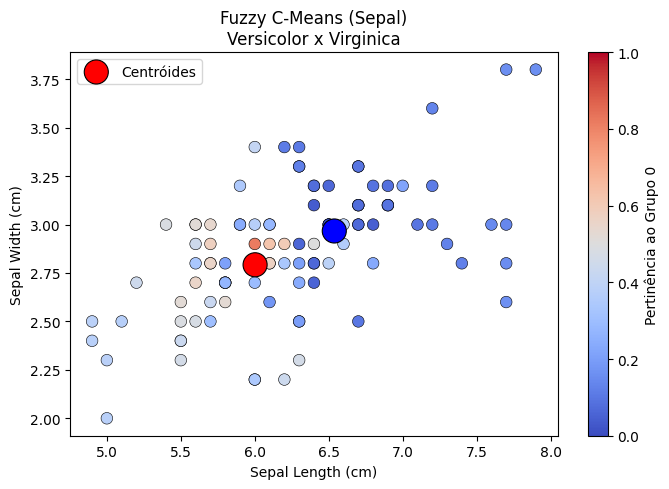

In [48]:
membership = U[:, 0]

fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 0], X[:, 1],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 0], C[:, 1], marker='o', s=300, c=['red', 'blue'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Sepal Length (cm)')
ax.set_ylabel('Sepal Width (cm)')
ax.set_title('Fuzzy C-Means (Sepal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()

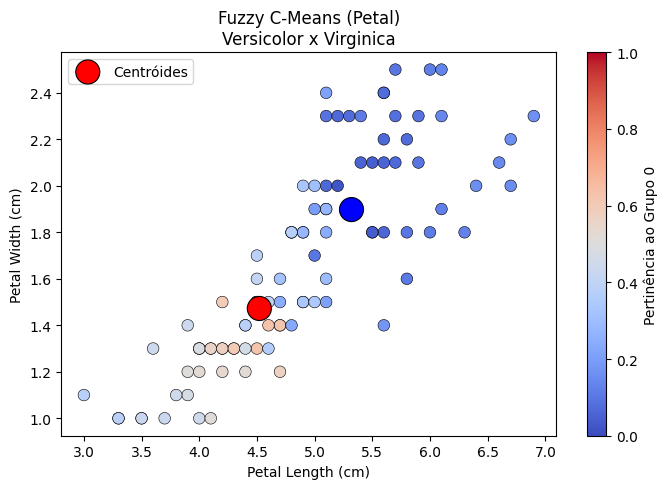

In [49]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(
    X[:, 2], X[:, 3],
    c=membership, cmap='coolwarm', vmin=0, vmax=1,
    edgecolors='k', linewidths=0.4, s=70
)

ax.scatter(C[:, 2], C[:, 3], marker='o', s=300, c=['red', 'blue'],
           edgecolors='k', linewidths=0.8, zorder=5, label='Centróides')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pertinência ao Grupo 0')
ax.set_xlabel('Petal Length (cm)')
ax.set_ylabel('Petal Width (cm)')
ax.set_title('Fuzzy C-Means (Petal)\nVersicolor x Virginica')
ax.legend()
plt.tight_layout()
plt.show()